## Tree-based models

In [1]:
%load_ext autoreload
%autoreload 2
import sys
sys.path.append("..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler

from src.evaluation import *
from src.visualization import plot_metric_surface

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier

In [2]:
x_train = pd.read_csv("../data/x_train.txt", sep=" ")
y_train = pd.read_csv("../data/y_train.txt")

scaler = MinMaxScaler()
x_train_scaled = pd.DataFrame(scaler.fit_transform(x_train), columns=x_train.columns)

y_train = y_train.squeeze()

In [3]:
feature_importance_df = pd.read_csv("../outputs/feature_importance_ranking.csv")

In [14]:

MODEL_CONFIGS = {
    "tree": lambda C: DecisionTreeClassifier(
        max_depth=C, random_state=42
    ),

    "rf": lambda C: RandomForestClassifier(
        n_estimators=200,
        max_depth=C,
        random_state=42,
        n_jobs=-1
    ),

    "extra": lambda C: ExtraTreesClassifier(
        n_estimators=200,
        max_depth=C,
        random_state=42,
        n_jobs=-1
    ),
}
C_VALUES = [3, 5, 10]
# C_VALUES = [3, 5, 10]
# K_VALUES = range(1, 21)
K_VALUES = range(1, 11)

TOP_N_VALUES = [50, 100, 250, 500, 1000]
# TOP_N_VALUES = [500, 1000]
all_results = []

sorted_features = feature_importance_df.sort_values("rf_rank")["feature"].values
print(f"First feature is: {sorted_features[0]}")

for model_name, model_fn in MODEL_CONFIGS.items():

    print(f"\nRunning model: {model_name}")

    for C in C_VALUES:

        print(f"  Depth/Complexity C={C}")

        for k in K_VALUES:

            selected_features = sorted_features[:k]
            X_sel = x_train_scaled[selected_features]

            model = model_fn(C)

            for t in TOP_N_VALUES:

                summary = cross_val_eval(
                    model=model,
                    X=X_sel,
                    y=y_train,
                    n_features=k,
                    model_name=f"{model_name}_C={C}_k={k}",
                    top_n=t
                )

                summary["model_type"] = model_name
                summary["C"] = C
                summary["k"] = k
                summary["top_n"] = t

                all_results.append(summary)

final_results = pd.DataFrame(all_results)

First feature is: V191

Running model: tree
  Depth/Complexity C=3
  Depth/Complexity C=5
  Depth/Complexity C=10

Running model: rf
  Depth/Complexity C=3
  Depth/Complexity C=5
  Depth/Complexity C=10

Running model: extra
  Depth/Complexity C=3
  Depth/Complexity C=5
  Depth/Complexity C=10


In [15]:
final_results.sort_values(by="score", ascending=False).head(20)


,accuracy,precision,recall,f1,profit,score,n_features,accuracy_std,precision_std,recall_std,f1_std,profit_std,score_std,model,threshold,top_n,model_type,C,k
204,0.5548,0.631,0.253617,0.361812,893.0,693.0,1,0.007791,0.019494,0.007823,0.011164,58.480766,58.480766,rf_C=5_k=1,None,1000,rf,5,1
154,0.5544,0.630,0.253214,0.361237,890.0,690.0,1,0.010015,0.025249,0.010097,0.014425,75.746287,75.746287,rf_C=3_k=1,None,1000,rf,3,1
304,0.5532,0.627,0.252005,0.359514,881.0,681.0,1,0.014132,0.035812,0.014288,0.020426,107.436027,107.436027,extra_C=3_k=1,None,1000,extra,3,1
354,0.5528,0.626,0.251606,0.358943,878.0,678.0,1,0.014377,0.036125,0.014471,0.020664,108.374351,108.374351,extra_C=5_k=1,None,1000,extra,5,1
4,0.5508,0.621,0.249595,0.356075,863.0,663.0,1,0.015320,0.038633,0.015454,0.022076,115.898663,115.898663,tree_C=3_k=1,None,1000,tree,3,1
54,0.5504,0.620,0.249192,0.355500,860.0,660.0,1,0.009072,0.023452,0.009265,0.013283,70.356236,70.356236,tree_C=5_k=1,None,1000,tree,5,1
404,0.5476,0.613,0.246381,0.351489,839.0,639.0,1,0.013831,0.034749,0.013920,0.019877,104.247302,104.247302,extra_C=10_k=1,None,1000,extra,10,1
9,0.5740,0.679,0.272913,0.389338,1037.0,637.0,2,0.007649,0.018507,0.007566,0.010740,55.520267,55.520267,tree_C=3_k=2,None,1000,tree,3,2
254,0.5472,0.612,0.245984,0.350921,836.0,636.0,1,0.008927,0.021679,0.008833,0.012551,65.038450,65.038450,rf_C=10_k=1,None,1000,rf,10,1
104,0.5432,0.602,0.241957,0.345179,806.0,606.0,1,0.017541,0.044244,0.017694,0.025278,132.730931,132.730931,tree_C=10_k=1,None,1000,tree,10,1


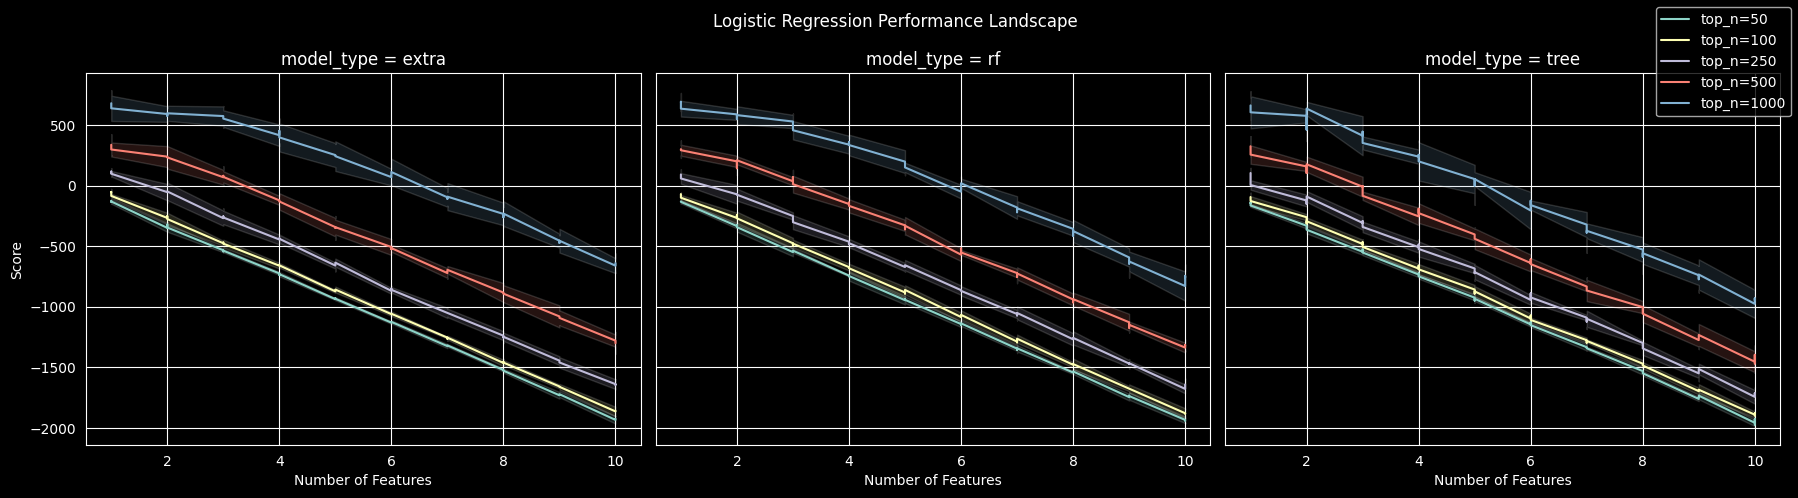

In [16]:
plot_metric_surface(
    df=final_results,
    x_col="n_features",
    y_col="score",
    split_col="model_type",
    line_col="top_n",
    std_col="score_std",
    title="Logistic Regression Performance Landscape",
    x_label="Number of Features",
    y_label="Score"
)